# **Project Name**     - Airbnb Bookings Analysis (Shamini S)

##### **Project Type**    - Airbnb_EDA
##### **Contribution**    - Individual

# **Project Summary**

**About the project**

This project is an exploratory data analysis of Airbnb listings in New York City from 2019. It looks at how listings are spread across the city's five boroughs, which kinds of stays hosts offer most often, and how nightly prices differ from one area to another.

**Data used**

The dataset holds 48,895 listings described by 16 columns: location (borough, neighbourhood, coordinates), room type, nightly price, minimum stay, review counts, the number of listings per host, and yearly availability. No duplicate rows were found. Missing `reviews_per_month` values were set to 0 (these are listings with no reviews), and the few rows with no listing name or host name were dropped.

**What was analysed**

* Average nightly price in each borough
* Share of listings by room type
* The ten neighbourhoods with the most listings
* Spread and outliers of prices within each borough
* Correlations between the numerical variables

**What the analysis shows**

* Manhattan is the most expensive borough on average, at just under $200 a night, while the Bronx is the cheapest.
* Entire homes/apartments and private rooms together make up about 98% of listings, and shared rooms only about 2%.
* Williamsburg and Bedford-Stuyvesant, both in Brooklyn, have the largest number of listings.
* Prices vary widely, with some listings priced as high as $10,000 a night, and price has only weak correlations with the other numerical variables.

**Why it matters**

Hosts can use the borough-level price ranges to price competitively and to see where competition is heaviest. Travelers can see which areas tend to be cheaper or more expensive. Platform stakeholders can see where supply is concentrated and which room types dominate.

# **GitHub Link -**

https://github.com/Shamini-tech/Airbnb-Analysis-Capstone-Project

# **Problem Statement**

Airbnb hosts operate in a crowded and competitive market, yet often lack clear, data-driven guidance on how listing attributes such as location, room type, and price influence their position in that market. Without this understanding, hosts may struggle to price competitively, choose where and what to list, and recognize how supply is distributed across the city. This project explores the Airbnb NYC 2019 listings data to uncover those patterns.

#### **Define Your Business Objective?**

The goal of this analysis is to turn listing data into actionable insights that:

1. **Support Pricing Strategy:** Show how prices differ across boroughs and how widely they vary within each one.
2. **Guide Listing Decisions:** Identify which room types and neighbourhoods dominate the market.
3. **Clarify Market Dynamics:** Reveal where supply is concentrated and which variables are related.
4. **Enable Data-Driven Decision-Making:** Give hosts, travelers, and stakeholders evidence to act on.


# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading, First View

In [ ]:
# Load Dataset
data = pd.read_csv('/content/AB_NYC_2019.csv')

# Dataset First Look
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns Count, Dataset Information

In [ ]:
# Dataset Shape
print("Dataset Shape:", data.shape)

# Dataset Info
data.info()

Dataset Shape: (48895, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_

#### Duplicate Values and Missing Values/Null Values

In [ ]:
# Check for duplicate values
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Check for missing values in each column
missing_values = data.isnull().sum()
print("\nMissing values per column:\n", missing_values[missing_values > 0])

Number of duplicate rows: 0

Missing values per column:
 name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


### What did you know about your dataset?

The dataset contains **48,895 rows and 16 columns** and is a mix of categorical and numerical variables. There are **no duplicate rows**. Missing values appear in four columns: `name` (16), `host_name` (21), `last_review` (10,052), and `reviews_per_month` (10,052). The identical counts for the last two columns suggest these are listings that have never been reviewed. These missing values are handled in the Data Wrangling section.

## ***2. Understanding Your Variables***

### Dataset Describe

In [ ]:
# Statistical description of the dataset
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Observation: the minimum `price` is 0, which is not a valid listing price. The maximum is 10,000, far above the mean (about 153) and the median (106), so the price distribution is heavily right-skewed.

### Variables Description

* **id:** Identifier for each listing.
* **name:** Name of the listing.
* **host_id:** Identifier for the host.
* **host_name:** Name of the host.
* **neighbourhood_group:** Borough in which the listing is located.
* **neighbourhood:** Specific neighbourhood name.
* **latitude:** Latitude of the listing.
* **longitude:** Longitude of the listing.
* **room_type:** Type of room (e.g., entire home/apt, private room, shared room).
* **price:** Price of the listing per night.
* **minimum_nights:** Minimum number of nights required to book.
* **number_of_reviews:** Total number of reviews.
* **last_review:** Date of the last review.
* **reviews_per_month:** Average number of reviews per month.
* **calculated_host_listings_count:** Number of listings managed by the host.
* **availability_365:** Number of days the listing is available in a year.

## ***3. Data Wrangling***

### Data Wrangling Code

**Handling missing values:**
* `reviews_per_month` is filled with 0, since a missing value here means the listing has no reviews.
* Rows with a missing `name` or `host_name` are dropped, since these identify the listing and host.

In [ ]:
# Data Wrangling: Filling missing values for reviews_per_month with 0
data['reviews_per_month'].fillna(0, inplace=True)

# Dropping rows where name or host_name are missing (or filling them)
data.dropna(subset=['name', 'host_name'], inplace=True)

# Checking missing values again to confirm they are handled
print("Remaining missing values:\n", data.isnull().sum())

Remaining missing values:
 id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10037
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


/tmp/ipykernel_2019/422606665.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['reviews_per_month'].fillna(0, inplace=True)


Missing values are now resolved in every column except `last_review` (10,037 remaining), which is intentionally left as-is because it is not used in the analysis below.

## ***4. Data Visualization, Storytelling & Experimenting with Charts : Understand the Relationships Between Variables***

#### Analysis 1 >> Average Price by Neighbourhood Group

/tmp/ipykernel_2019/361815560.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price_by_group, x='neighbourhood_group', y='price', palette='muted')


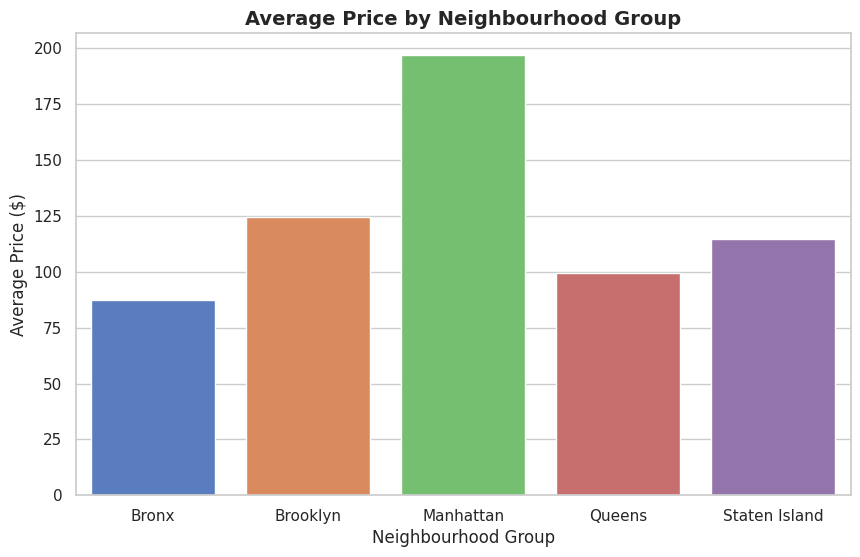

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Group by neighbourhood group and find average price
avg_price_by_group = data.groupby('neighbourhood_group')['price'].mean().reset_index()

# Plotting Average Price by Neighbourhood Group
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_price_by_group, x='neighbourhood_group', y='price', palette='muted')
plt.title('Average Price by Neighbourhood Group', fontsize=14, fontweight='bold')
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing a single metric (average price) across a small number of categories (boroughs), making differences easy to read at a glance.

##### 2. What is/are the insight(s) found from the chart?

* Manhattan has the highest average price, at roughly $195–200 per night, well above every other borough.
* Brooklyn is second (about $125), followed by Staten Island (about $115) and Queens (about $100).
* The Bronx has the lowest average price (about $85–90).

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Business Impact:**
  1. **Pricing Benchmarks:** Hosts can set prices in line with their borough's average.
  2. **Targeted Marketing:** Premium offerings can be directed at Manhattan and Brooklyn, and value-focused offerings at the Bronx and Queens.
* **Potential Negative Growth:**
  1. **Averages Can Mislead:** The mean is pulled upward by very expensive listings (the overall mean is about 153 against a median of 106), so hosts should not treat the borough average as a typical price.

#### Analysis 2 >> Most Preferred Room Types

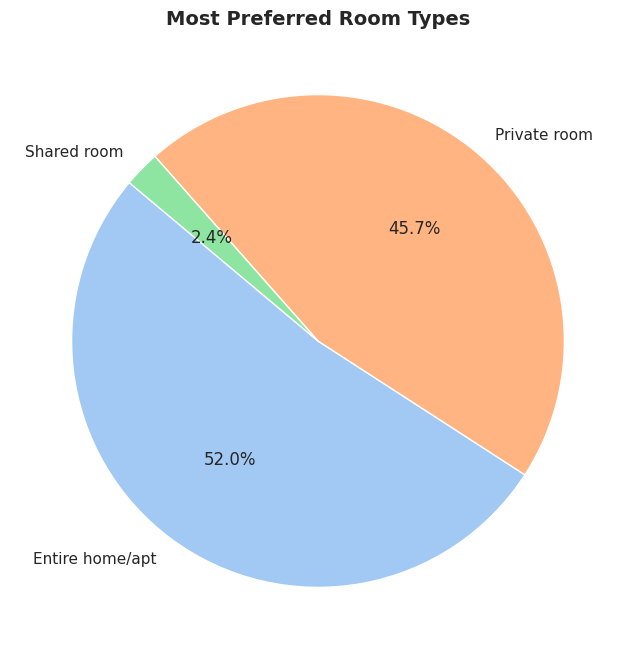

In [ ]:
# Room types distribution
room_type_counts = data['room_type'].value_counts()

# Plotting Room Types pie chart
plt.figure(figsize=(8, 8))
plt.pie(room_type_counts, labels=room_type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Most Preferred Room Types', fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart shows each room type's proportion of the whole, which suits a variable with only three categories.

##### 2. What is/are the insight(s) found from the chart?

Room types by share of listings:
1. **Entire home/apt:** 52.0%
2. **Private room:** 45.7%
3. **Shared room:** 2.4%

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Business Impact:**
  1. **Entire Homes/Apartments:** At 52.0% of listings, they are the most common offering and a proven format for hosts.
  2. **Private Rooms:** At 45.7%, they are a strong alternative for hosts who do not list an entire property.
* **Potential Negative Growth:**
  1. **Shared Rooms:** At only 2.4%, shared rooms are a very small segment, so heavy investment in them is risky.
  2. **Supply vs. Demand:** This chart shows the share of *listings*, which reflects supply. Guest demand would need to be confirmed with booking or review data.

#### Analysis 3 >> Most Popular Neighbourhoods (Top 10 by Number of Listings)

/tmp/ipykernel_2019/4076063732.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_neighborhoods, x='neighbourhood', y='count', palette='Blues_r')


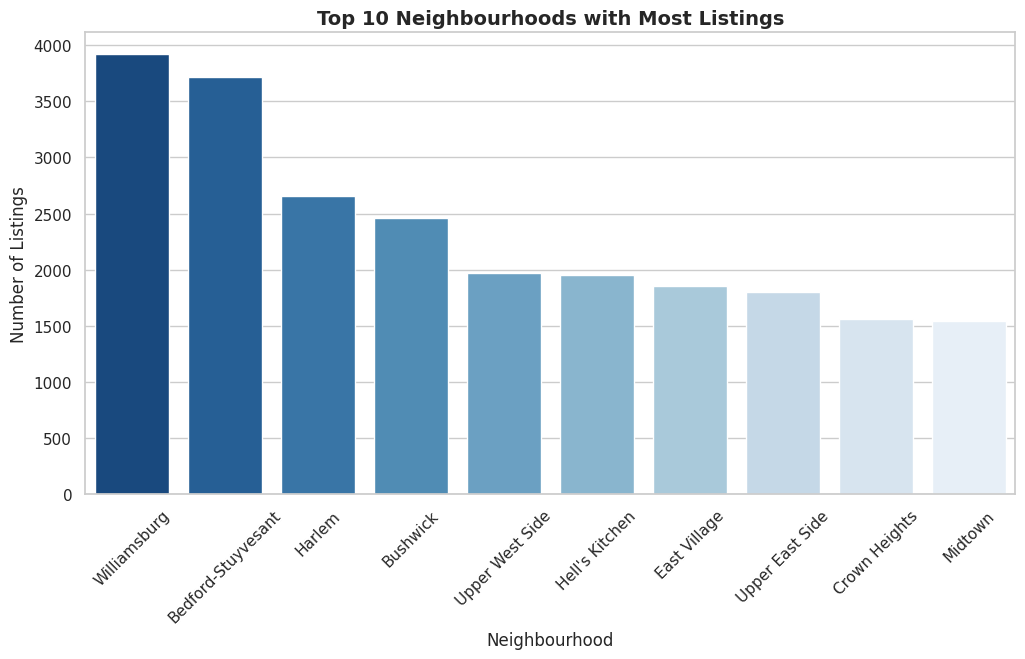

In [ ]:
# Top 10 neighborhoods with highest number of listings
top_neighborhoods = data['neighbourhood'].value_counts().head(10).reset_index()
top_neighborhoods.columns = ['neighbourhood', 'count']

# Plotting Top 10 Neighbourhoods
plt.figure(figsize=(12, 6))
sns.barplot(data=top_neighborhoods, x='neighbourhood', y='count', palette='Blues_r')
plt.title('Top 10 Neighbourhoods with Most Listings', fontsize=14, fontweight='bold')
plt.xlabel('Neighbourhood', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart sorted from highest to lowest makes it easy to rank neighbourhoods and see how quickly listing counts fall off.

##### 2. What is/are the insight(s) found from the chart?

* **Williamsburg** (about 3,900 listings) and **Bedford-Stuyvesant** (about 3,700) lead by a clear margin, followed by **Harlem** (about 2,650) and **Bushwick** (about 2,450).
* The remaining six neighbourhoods (Upper West Side, Hell's Kitchen, East Village, Upper East Side, Crown Heights, and Midtown) each have roughly 1,500–2,000 listings.
* The top 10 is split between Brooklyn (Williamsburg, Bedford-Stuyvesant, Bushwick, Crown Heights) and Manhattan (the other six).

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Business Impact:**
  1. **Market Presence:** These neighbourhoods are where Airbnb activity is concentrated, which indicates established traveler interest.
  2. **Targeted Strategy:** Marketing and operational effort can be focused on high-activity areas.
* **Potential Negative Growth:**
  1. **Market Saturation:** A high listing count also means more competition, so new hosts in these areas may find it harder to stand out.

#### Analysis 4 >> Price Variation by Neighbourhood Group

/tmp/ipykernel_2019/631740263.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data[data['price'] < 500], x='neighbourhood_group', y='price', palette='Set2')


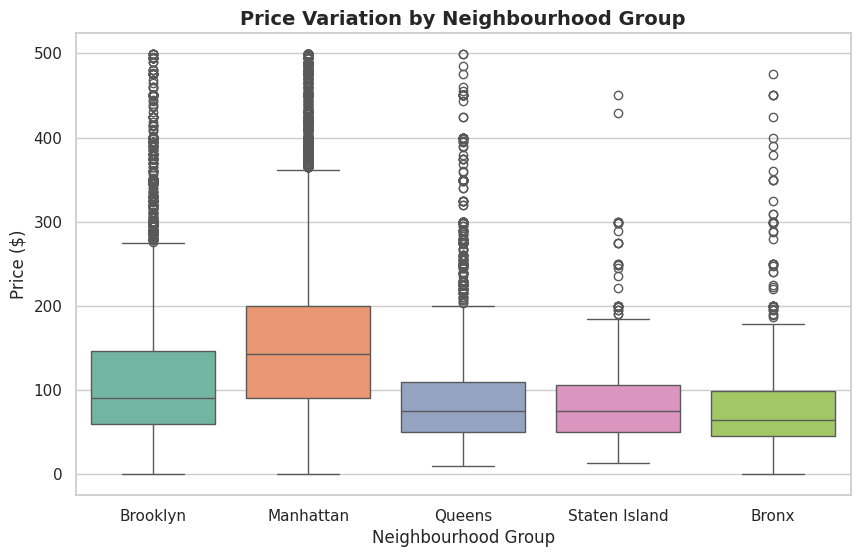

In [ ]:
# Price variation by neighbourhood group (filtering prices under $500 for better visualization)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[data['price'] < 500], x='neighbourhood_group', y='price', palette='Set2')
plt.title('Price Variation by Neighbourhood Group', fontsize=14, fontweight='bold')
plt.xlabel('Neighbourhood Group', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot summarizes the median, spread, and outliers of price for each borough in one view, which a bar chart of averages cannot show. Prices are filtered to under $500 so that the boxes remain readable.

##### 2. What is/are the insight(s) found from the chart?

* **Manhattan** has the highest median price (about $140) and the widest middle range of prices (roughly $90–$200).
* **Brooklyn** has a median of about $90, with a middle range of roughly $60–$145.
* **Queens and Staten Island** have similar medians (about $75) and fairly compact price ranges.
* **The Bronx** has the lowest median (about $65) and the narrowest spread.
* Every borough has many high-priced outliers, most visibly Manhattan and Brooklyn.

##### 3. Will the gained insights help create a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* **Positive Business Impact:**
  1. **Realistic Price Ranges:** Hosts can position their price within the typical range for their borough rather than relying on a single average.
  2. **Premium Opportunities:** The wide spread in Manhattan and Brooklyn shows room for differentiated, higher-priced listings.
* **Potential Negative Growth:**
  1. **Overpricing Risk:** Pricing well above the typical range without clear differentiation may reduce a listing's competitiveness.

### ***Additional - Chart Correlation Heatmap***

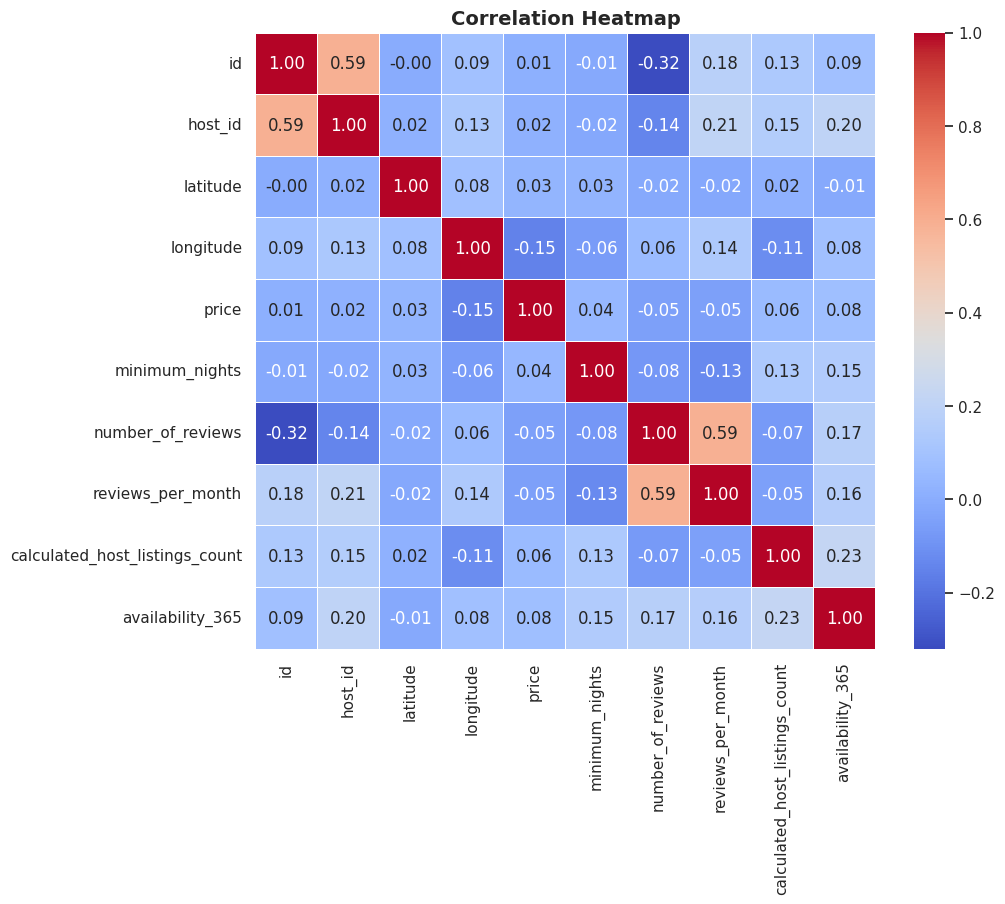

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_data = data.select_dtypes(include=['float64', 'int64'])
correlation = numeric_data.corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap shows the relationships between all numerical variables in a single view.

##### 2. What is/are the insight(s) found from the chart?

* `number_of_reviews` and `reviews_per_month` show a moderate positive correlation (0.59), as expected since both measure review activity.
* `price` has only weak correlations with every other variable (none stronger than about 0.15 in absolute value), so no single numerical variable explains price on its own.
* `calculated_host_listings_count` has a weak positive correlation with `availability_365` (0.23), suggesting hosts with more listings tend to keep them available for more days.
* `id` and `host_id` (0.59), and `id` and `number_of_reviews` (-0.32), appear in the matrix, but these are identifier columns, so the values are not meaningful business relationships.

# **Conclusion**

**Key Findings and Insights:**
1. **Neighborhood Demand & Pricing**: Manhattan commands the highest average listing prices among all neighbourhood groups, making it the most lucrative area for hosts. Meanwhile, areas like Brooklyn (specifically Williamsburg and Bedford-Stuyvesant) dominate the highest volume of total listings.
2. **Preferred Room Types**: Entire homes/apartments and private rooms make up over 97% of all listings combined, indicating that guests heavily prefer private or full-apartment accommodations over shared rooms.
3. **Price Outliers**: Most listings fall below $500, but luxury outliers stretch up to $10,000 per night, demonstrating a diverse range of accommodations from budget stays to high-end luxury properties.
4. **Review Activity**: Listings with higher review frequencies often correlate with specific popular locations and room types, showing strong user engagement in high-traffic tourist zones.

### ***End of EDA Capstone Project***